# Imports e Configuração

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import os
import joblib

from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

TECNICA_ATUAL = "SMOTE" 
PASTA_DADOS = os.path.join("..", "PreProcessing", TECNICA_ATUAL)

NOME_X_TRAIN = f"X_train_pronto_{TECNICA_ATUAL}.csv"
NOME_Y_TRAIN = f"y_train_pronto_{TECNICA_ATUAL}.csv"
NOME_X_TEST  = f"X_test_pronto_{TECNICA_ATUAL}.csv"
NOME_Y_TEST  = f"y_test_pronto_{TECNICA_ATUAL}.csv"

print(f"📘 Iniciando Treinamento KNN")
print(f"📂 Buscando dados no caminho relativo: {PASTA_DADOS}")

📘 Iniciando Treinamento KNN
📂 Buscando dados no caminho relativo: ..\PreProcessing\SMOTE


# Carregamento de dados

In [3]:
path_X_train = os.path.join(PASTA_DADOS, NOME_X_TRAIN)
path_y_train = os.path.join(PASTA_DADOS, NOME_Y_TRAIN)
path_X_test  = os.path.join(PASTA_DADOS, NOME_X_TEST)
path_y_test  = os.path.join(PASTA_DADOS, NOME_Y_TEST)

arquivos_necessarios = [path_X_train, path_y_train, path_X_test, path_y_test]
arquivos_faltando = [arq for arq in arquivos_necessarios if not os.path.exists(arq)]

if arquivos_faltando:
    print("ERRO: Arquivos não encontrados no caminho especificado:")
    for arq in arquivos_faltando:
        print(f"   -> {arq}")
else:
    try:
        X_train = pd.read_csv(path_X_train)
        y_train = pd.read_csv(path_y_train).values.ravel()
        
        X_test = pd.read_csv(path_X_test)
        y_test = pd.read_csv(path_y_test).values.ravel()
        
        print("✅ Dados carregados com sucesso!")
        print(f"Amostras de Treino: {X_train.shape[0]}")
        print(f"Amostras de Teste:  {X_test.shape[0]}")

    except Exception as e:
        print(f"Erro inesperado ao ler os arquivos:\n{e}")

✅ Dados carregados com sucesso!
Amostras de Treino: 1701
Amostras de Teste:  293


# Treinamento

In [4]:
param_grid = {
    'n_neighbors': [3, 5, 7, 9], 
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}

grid = GridSearchCV(KNeighborsClassifier(), param_grid, refit=True, cv=3, n_jobs=-1, verbose=1)
grid.fit(X_train, y_train)

print(f"Melhores parâmetros encontrados: {grid.best_params_}")
modelo_knn = grid.best_estimator_

Fitting 3 folds for each of 16 candidates, totalling 48 fits
Melhores parâmetros encontrados: {'metric': 'euclidean', 'n_neighbors': 3, 'weights': 'distance'}


# Avaliação

📊 Avaliando o modelo com os dados de Teste...

--- Relatório de Classificação ---
              precision    recall  f1-score   support

Saudável (0)       0.90      0.84      0.87       138
 Benigno (1)       0.78      0.64      0.71       142
  Câncer (2)       0.04      0.15      0.07        13

    accuracy                           0.71       293
   macro avg       0.58      0.55      0.55       293
weighted avg       0.81      0.71      0.75       293



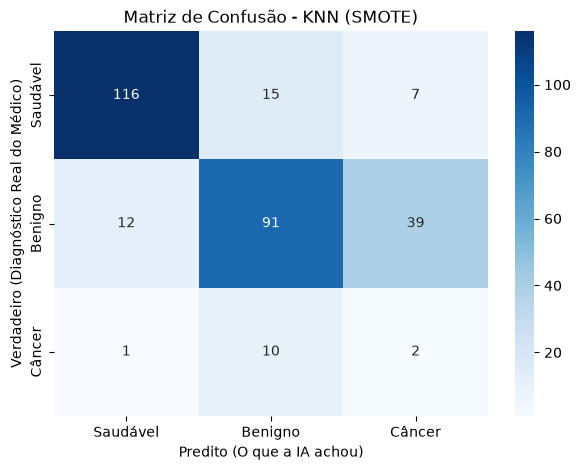

💾 Modelo final salvo com sucesso em: ..\PreProcessing\SMOTE\modelo_knn_smote.pkl


In [5]:
print("📊 Avaliando o modelo com os dados de Teste...\n")

y_pred = modelo_knn.predict(X_test)

print("--- Relatório de Classificação ---")
print(classification_report(y_test, y_pred, target_names=['Saudável (0)', 'Benigno (1)', 'Câncer (2)']))

plt.figure(figsize=(7, 5))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Saudável', 'Benigno', 'Câncer'],
            yticklabels=['Saudável', 'Benigno', 'Câncer'])

plt.title(f"Matriz de Confusão - KNN ({TECNICA_ATUAL})")
plt.ylabel("Verdadeiro (Diagnóstico Real do Médico)")
plt.xlabel("Predito (O que a IA achou)")
plt.show()

caminho_modelo = os.path.join(PASTA_DADOS, f'modelo_knn_{TECNICA_ATUAL.lower()}.pkl')
joblib.dump(modelo_knn, caminho_modelo)
print(f"💾 Modelo final salvo com sucesso em: {caminho_modelo}")